# The Planar Grossman-Larson (PGL) Hopf Algebra

The **planar Grossman-Larson (PGL) Hopf algebra** is the ordered (planar) version of the classical Grossman-Larson Hopf algebra. It operates on **planar rooted trees** (`PlanarTree`), where the left-to-right ordering of siblings matters.

Key properties:
- The **unit** is the single-vertex tree (bullet).
- The **product** is the planar grafting product, which sums over all monotone assignments of branches to vertices, interleaving assigned branches at all positions among existing children while preserving left-to-right order.
- The **coproduct** splits children of the root into all possible subsets, preserving planar order on both sides. It is **cocommutative**.
- The algebra is **noncommutative** (the product does not commute).
- Unlike the non-planar GL, the antipode satisfies $S^2 \neq \mathrm{id}$ in general.

In [1]:
import kauri as kr
import kauri.pgl as pgl

PT = kr.PlanarTree

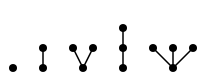

In [2]:
# Define some standard planar trees
bullet = PT([])           # single-vertex tree
chain2 = PT([[]])         # B+(bullet)
cherry = PT([[], []])     # B+(bullet, bullet)
chain3 = PT([[[]]])       # B+(B+(bullet))
corolla3 = PT([[], [], []])  # B+(bullet, bullet, bullet)

kr.display(bullet, chain2, cherry, chain3, corolla3)

## Planar Grafting Product

For trees $s$ and $t = B_+(t_1, \ldots, t_k)$, the PGL product $s \cdot_{PGL} t$ sums over all **monotone assignments** of the branches $t_1, \ldots, t_k$ to vertices of $s$ (preserving left-to-right order), **interleaving** the assigned branches at all positions among existing children.

Verified against Hoffman (2007), lines 720--779, arxiv [0710.3739](https://arxiv.org/abs/0710.3739).

### The bullet is the unit

Since $\bullet = B_+()$ has no branches, the product $s \cdot \bullet$ simply returns $s$ (the only monotone assignment is the empty one). Similarly, $\bullet \cdot t = t$ since the only vertex to assign branches to is the root of $\bullet$, and interleaving with zero existing children gives the original tree.

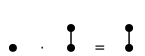

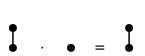

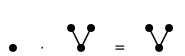

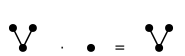

In [3]:
# bullet is the two-sided unit
kr.display(bullet, "·", chain2, "=", pgl.product(bullet, chain2))
kr.display(chain2, "·", bullet, "=", pgl.product(chain2, bullet))
kr.display(bullet, "·", cherry, "=", pgl.product(bullet, cherry))
kr.display(cherry, "·", bullet, "=", pgl.product(cherry, bullet))

Here $B_+(\bullet)$ has 1 branch (bullet). We assign it to one of the 2 vertices of $s = B_+(\bullet)$.

- **Assigned to root** (which has 1 existing child): interleaving 1 new branch among 1 existing child gives $\binom{2}{1} = 2$ positions, both producing cherry.
- **Assigned to the leaf** (which has 0 existing children): the leaf gains 1 child, producing chain3.

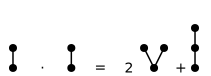

In [4]:
kr.display(chain2, "·", chain2, "=", pgl.product(chain2, chain2))

### Hoffman's notation: cherry $\circ$ chain2

In Hoffman's convention (arxiv 0710.3739, lines 720--744), $\text{cherry} \circ \text{chain2}$ corresponds to `pgl.product(chain2, cherry)` in kauri (the right operand's branches are grafted onto the left operand).

The cherry $= B_+(\bullet, \bullet)$ has 2 branches. $B_+(\bullet)$ has 2 vertices. The monotone assignments $\{(0,0), (0,1), (1,1)\}$ give:

- **(0,0)**: Both branches go to root (1 existing child). Interleaving 2 new branches among 1 existing gives $\binom{3}{1} = 3$ orderings, all producing the corolla.
- **(0,1)**: First branch to root, second to leaf. Root gets 1 new branch interleaved with 1 existing child ($\binom{2}{1} = 2$ ways). Leaf gets 1 new child.
- **(1,1)**: Both branches to the leaf. Leaf gets 2 new children interleaved with 0 existing.

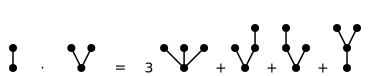

In [5]:
# cherry o chain2 in Hoffman = pgl.product(chain2, cherry) in kauri
kr.display(chain2, "·", cherry, "=", pgl.product(chain2, cherry))

### Hoffman's notation: chain2 $\circ$ cherry

In Hoffman's convention (lines 758--779), $\text{chain2} \circ \text{cherry}$ corresponds to `pgl.product(cherry, chain2)` in kauri.

$B_+(\bullet)$ has 1 branch. The cherry has 3 vertices (root with 2 children). The monotone assignments place the single branch at vertex 0, 1, or 2:

- **Vertex 0** (root with 2 existing children): interleaving 1 new branch gives $\binom{3}{1} = 3$ positions, all producing the corolla.
- **Vertex 1** (left leaf, 0 children): the leaf gains 1 child.
- **Vertex 2** (right leaf, 0 children): the leaf gains 1 child.

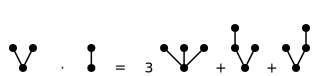

In [6]:
# chain2 o cherry in Hoffman = pgl.product(cherry, chain2) in kauri
kr.display(cherry, "·", chain2, "=", pgl.product(cherry, chain2))

### Noncommutativity

The two products above are not equal: cherry $\circ$ chain2 has a $B_+(\text{cherry})$ term that chain2 $\circ$ cherry lacks. This confirms that the PGL product is **noncommutative**.

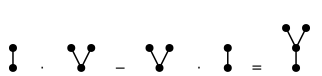

In [7]:
# The difference is nonzero
diff = pgl.product(chain2, cherry) - pgl.product(cherry, chain2)
kr.display(chain2, "·", cherry, "−", cherry, "·", chain2, "=", diff)

## Coproduct

The PGL coproduct splits the children of the root into all possible subsets, preserving sibling order on both sides:

$$\Delta_{PGL}(t) = \sum_{S \subseteq \{1,\ldots,k\}} B_+(t_i : i \in S) \otimes B_+(t_j : j \notin S)$$

This is the same structure as the non-planar GL coproduct and is **cocommutative**.

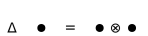

In [8]:
kr.display("Δ", bullet, "=", pgl.coproduct(bullet))

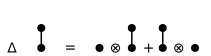

In [9]:
kr.display("Δ", chain2, "=", pgl.coproduct(chain2))

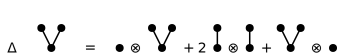

In [10]:
kr.display("Δ", cherry, "=", pgl.coproduct(cherry))

### Different planar orderings give different coproducts

Since sibling order is preserved on both sides, the trees $B_+(\bullet, [\![\,]\!])$ and $B_+([\![\,]\!], \bullet)$ have different coproducts.

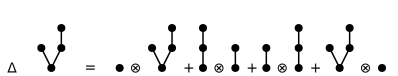

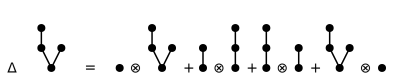

Equal: False


In [11]:
t1 = PT([[], [[]]])   # B+(bullet, chain2)
t2 = PT([[[]], []])    # B+(chain2, bullet)

kr.display("Δ", t1, "=", pgl.coproduct(t1))
kr.display("Δ", t2, "=", pgl.coproduct(t2))
print("Equal:", pgl.coproduct(t1) == pgl.coproduct(t2))

## Antipode

The PGL antipode is defined recursively:

$$S(\bullet) = \bullet, \qquad S(t) = -t - \sum_{\substack{S \subset \{1,\ldots,k\} \\ S \neq \emptyset,\, S \neq \{1,\ldots,k\}}} S(B_+(t_i : i \in S)) \cdot_{PGL} B_+(t_j : j \notin S)$$

Since the PGL product is noncommutative, the antipode is an **anti-homomorphism**.

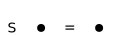

In [12]:
kr.display("S", bullet, "=", pgl.antipode(bullet))

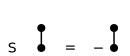

In [13]:
kr.display("S", chain2, "=", pgl.antipode(chain2))

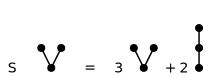

In [14]:
kr.display("S", cherry, "=", pgl.antipode(cherry))

### $S^2 \neq \mathrm{id}$ in PGL

Unlike the non-planar GL Hopf algebra where $S^2 = \mathrm{id}$, the PGL antipode does **not** satisfy $S^2 = \mathrm{id}$ in general. This is because PGL is neither commutative nor cocommutative (it is cocommutative, but non-commutative; $S^2 = \mathrm{id}$ holds when the algebra is both commutative and cocommutative, or more generally when $S$ is an involution).

For primitive elements (trees with 0 or 1 children of the root, such as bullets and chains), $S^2 = \mathrm{id}$ does hold. But for multi-child trees like cherry, it fails.

In [15]:
# S^2 = id for bullet and chain2
print("S^2(bullet) == bullet:", pgl.antipode(pgl.antipode(bullet)) == bullet.as_forest_sum())
print("S^2(chain2) == chain2:", pgl.antipode(pgl.antipode(chain2)) == chain2.as_forest_sum())

S^2(bullet) == bullet: True
S^2(chain2) == chain2: True


S^2(cherry) == cherry: False


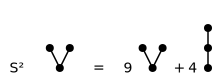

In [16]:
# S^2 != id for cherry
s2_cherry = pgl.antipode(pgl.antipode(cherry))
print("S^2(cherry) == cherry:", s2_cherry == cherry.as_forest_sum())
kr.display("S²", cherry, "=", s2_cherry)

## Hopf Algebra Axioms

### Antipode property: $\mu \circ (S \otimes \mathrm{id}) \circ \Delta = \eta \circ \varepsilon$

The defining property of the antipode states that applying $S$ to the left tensor factor and then multiplying should yield the counit (times the unit). We verify this for all planar trees up to order 4 using the convolution product of maps.

In [17]:
result = True

# Verify mu(S (x) id)(Delta(t)) = counit(t) * bullet
# We compute this directly: for each coproduct term c * left (x) right,
# accumulate c * pgl.product(S(left), right) and check the result.
for n in range(1, 5):
    for t in kr.planar_trees_of_order(n):
        cp = pgl.coproduct(t)
        total = kr.ForestSum(())
        for c, lf, rf in cp:
            left = lf.tree_list[0]
            right = rf.tree_list[0]
            s_left = pgl.antipode(left)
            total = total + c * pgl.product(s_left, right)
        total = total.simplify()
        expected = pgl.counit(t) * PT([]).as_forest_sum()
        if total != expected:
            result = False
            break

print("Antipode property holds for all planar trees up to order 4:", result)

Antipode property holds for all planar trees up to order 4: True


### Counit

The counit satisfies $\varepsilon(\bullet) = 1$ and $\varepsilon(t) = 0$ for all trees with $|t| > 1$.

In [18]:
print("counit(bullet) =", pgl.counit(bullet))
print("counit(chain2) =", pgl.counit(chain2))
print("counit(cherry) =", pgl.counit(cherry))
print("counit(chain3) =", pgl.counit(chain3))

counit(bullet) = 1
counit(chain2) = 0
counit(cherry) = 0
counit(chain3) = 0


## Comparison with GL

The planar GL and non-planar GL Hopf algebras share the same **coproduct structure** (subset-splitting of children), but differ in their product:

- **GL product**: sums over all assignments of branches to vertices (all functions, not just monotone).
- **PGL product**: sums over **monotone** assignments with **interleaving**, preserving the planar structure.

Another key difference: the non-planar GL satisfies $S^2 = \mathrm{id}$, while PGL does not.

In [19]:
import kauri.gl as gl

# GL: S^2 = id always holds
t = kr.Tree([[], []])
print("GL: S^2(cherry) == cherry:",
      (gl.antipode & gl.antipode)(t) == t.as_forest_sum())

# PGL: S^2 != id for cherry
print("PGL: S^2(cherry) == cherry:",
      pgl.antipode(pgl.antipode(cherry)) == cherry.as_forest_sum())

GL: S^2(cherry) == cherry: True
PGL: S^2(cherry) == cherry: False


## Convolution Product of Maps

For scalar-valued maps $f, g$, the **PGL convolution product** is defined by:

$$(f \cdot g)(t) = \mu \circ (f \otimes g) \circ \Delta_{PGL}(t)$$

The functions `pgl.map_product` and `pgl.map_power` implement this.

In [20]:
f = kr.Map(lambda t: t.nodes())

# Convolution square
f2 = pgl.map_power(f, 2)

for t in kr.planar_trees_of_order(1):
    print(f"f^2({t}) = {f2(t)}")
for t in kr.planar_trees_of_order(2):
    print(f"f^2({t}) = {f2(t)}")
for t in kr.planar_trees_of_order(3):
    print(f"f^2({t}) = {f2(t)}")

f^2([]) = 1
f^2([[]]) = 4
f^2([[], []]) = 14
f^2([[[]]]) = 6


### Convolution inverse: $f \cdot f^{-1} = \varepsilon$

For a scalar-valued map $f$ with $f(\bullet) \neq 0$, the convolution inverse $f^{-1}$ satisfies $f \cdot f^{-1} = \varepsilon$.

In [21]:
from math import isclose

f = kr.Map(lambda t: t.nodes())
f_inv = pgl.map_power(f, -1)
f_times_finv = pgl.map_product(f, f_inv)

result = True
for n in range(1, 5):
    for t in kr.planar_trees_of_order(n):
        val = f_times_finv(t)
        expected = pgl.counit(t)
        if not isclose(val, expected, abs_tol=1e-10):
            result = False
            break

print("f * f^(-1) = counit for all planar trees up to order 4:", result)

f * f^(-1) = counit for all planar trees up to order 4: True
